In [66]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import pandas as pd 
import numpy as np 
import scipy as sp 
import json 
import matplotlib.pyplot as plt

import os 
from pathlib import Path 

import ast 

In [68]:
wd = os.getcwd()
wd

'c:\\Users\\andre\\Repositories\\FTZ_model_2.0\\exp_output'

In [69]:
file_name = "results_test_oldbudget.json"
data_path2 = os.path.join(wd, file_name)

data_path2


'c:\\Users\\andre\\Repositories\\FTZ_model_2.0\\exp_output\\results_test_oldbudget.json'

In [70]:
# Load the data into a pandas DataFrame.

df = pd.read_csv(data_path2)


In [ ]:
df.head

,env_name,run,algorithm,seed,best_curve,best_value,best_genome,all_best_genomes,elapsed_sec,success,error
0,Linear_standard,4,flat,574010,"[216.6, 217.35, 220.05, 220.05, 220.65, 222.15...",222.15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",78.960089,True,NaN
1,Linear_standard,2,flat,522761,"[217.5, 217.5, 217.5, 219.3, 222.15, 222.15, 2...",222.15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",79.228748,True,NaN
2,Linear_standard,1,flat,68851,"[216.0, 219.3, 220.05, 222.15, 222.15, 222.15,...",222.15,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",79.571891,True,NaN
3,Linear_standard,3,flat,761303,"[215.7, 217.05, 218.7, 220.65, 220.65, 220.65,...",222.15,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",79.624652,True,NaN
4,Linear_standard,6,flat,666291,"[212.7, 218.7, 220.65, 220.65, 222.15, 222.15,...",222.15,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",80.820649,True,NaN


# Mean Curve Construction 

In [72]:
df_curves = df[['env_name','run','algorithm','best_curve']].copy()
df_curves.head(5)

,env_name,run,algorithm,best_curve
0,Linear_standard,4,flat,"[216.6, 217.35, 220.05, 220.05, 220.65, 222.15..."
1,Linear_standard,2,flat,"[217.5, 217.5, 217.5, 219.3, 222.15, 222.15, 2..."
2,Linear_standard,1,flat,"[216.0, 219.3, 220.05, 222.15, 222.15, 222.15,..."
3,Linear_standard,3,flat,"[215.7, 217.05, 218.7, 220.65, 220.65, 220.65,..."
4,Linear_standard,6,flat,"[212.7, 218.7, 220.65, 220.65, 222.15, 222.15,..."


In [73]:
def safe_parse_json(x):
    if isinstance(x, float) and np.isnan(x):
        return np.nan
    
    if isinstance(x, str):
        x_clean = x.replace("'", '"')
        try:

            return json.loads(x_clean)
        except json.JSONDecodeError:
            try:
                return ast.literal_eval(x)
            except Exception:
                return np.nan
    return x

In [74]:
df_curves['best_curve'].apply(safe_parse_json)

0      [216.6, 217.35, 220.05, 220.05, 220.65, 222.15...
1      [217.5, 217.5, 217.5, 219.3, 222.15, 222.15, 2...
2      [216.0, 219.3, 220.05, 222.15, 222.15, 222.15,...
3      [215.7, 217.05, 218.7, 220.65, 220.65, 220.65,...
4      [212.7, 218.7, 220.65, 220.65, 222.15, 222.15,...
                             ...                        
415    [342.2, 341.45, 342.5, 342.35, 341.3, 341.9, 3...
416    [342.5, 340.4, 342.2, 345.5, 340.25, 341.45, 3...
417    [342.8, 339.8, 345.35, 342.35, 345.95, 341.0, ...
418    [344.15, 340.25, 342.35, 341.15, 342.5, 340.4,...
419    [340.25, 341.9, 343.25, 343.85, 344.75, 341.45...
Name: best_curve, Length: 420, dtype: object

In [75]:
df_curves['best_curve'].apply(type).value_counts()

df_curves = df_curves.dropna(subset=['best_curve'])

In [76]:
df_curves['best_curve'] = df_curves['best_curve'].apply(json.loads)

In [88]:
df_curves['best_curve'] = df_curves['best_curve'].apply(np.array)

df_curves = df_curves.reset_index(drop=True)

In [89]:

max_len = df_curves["best_curve"].map(len).max()

df_expanded = pd.DataFrame(df_curves["best_curve"].to_list(), index=df_curves.index)

df_expanded.columns = [f"gen_{i}" for i in range(max_len)]
df_expanded = pd.concat([df[["env_name", "algorithm"]], df_expanded], axis=1)



In [90]:
grouped = df_expanded.groupby(["env_name", "algorithm"])
mean_curves = grouped.mean().reset_index()
std_curves = grouped.std().reset_index()



## Analysis of strange Result 


In [98]:
env_name = 'Assembly Tree_standard'

analysis = (
    df_expanded[df_expanded['env_name'] == env_name]
    .groupby('algorithm')
)

In [100]:
analysis.head(10)

,env_name,algorithm,gen_0,gen_1,gen_2,gen_3,gen_4,gen_5,gen_6,gen_7,...,gen_21,gen_22,gen_23,gen_24,gen_25,gen_26,gen_27,gen_28,gen_29,gen_30
120,Assembly Tree_standard,flat,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30,...,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30
121,Assembly Tree_standard,flat,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15,...,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15
122,Assembly Tree_standard,flat,738.10,738.10,738.10,738.10,738.10,738.10,738.10,738.10,...,738.10,738.10,738.10,738.10,738.10,738.10,738.10,738.10,738.10,738.10
123,Assembly Tree_standard,flat,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40,...,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40
124,Assembly Tree_standard,flat,686.65,686.65,686.65,686.65,686.65,686.65,686.65,686.65,...,686.65,686.65,686.65,686.65,686.65,686.65,686.65,686.65,686.65,686.65
125,Assembly Tree_standard,flat,725.20,725.20,725.20,725.20,725.20,725.20,725.20,725.20,...,725.20,725.20,725.20,725.20,725.20,725.20,725.20,725.20,725.20,725.20
126,Assembly Tree_standard,generic,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40,...,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40,747.40
127,Assembly Tree_standard,generic,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15,...,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15,670.15
128,Assembly Tree_standard,generic,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30,...,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30,721.30
129,Assembly Tree_standard,joint,676.15,676.15,676.15,676.15,676.15,676.15,676.15,676.15,...,676.15,676.15,676.15,676.15,676.15,676.15,676.15,676.15,676.15,676.15


In [95]:
grouped['env_name'].unique()

env_name                       algorithm
Assembly Tree_perturbed        flat               [Assembly Tree_perturbed]
                               generic            [Assembly Tree_perturbed]
                               joint              [Assembly Tree_perturbed]
                               pso                [Assembly Tree_perturbed]
                               random             [Assembly Tree_perturbed]
                                                         ...               
Tri-Spine Convergent_standard  flat         [Tri-Spine Convergent_standard]
                               generic      [Tri-Spine Convergent_standard]
                               joint        [Tri-Spine Convergent_standard]
                               pso          [Tri-Spine Convergent_standard]
                               random       [Tri-Spine Convergent_standard]
Name: env_name, Length: 70, dtype: object

In [97]:
analysis = grouped[grouped['env_name'] == 'Assembly Tree_standard']

KeyError: 'Column not found: False'

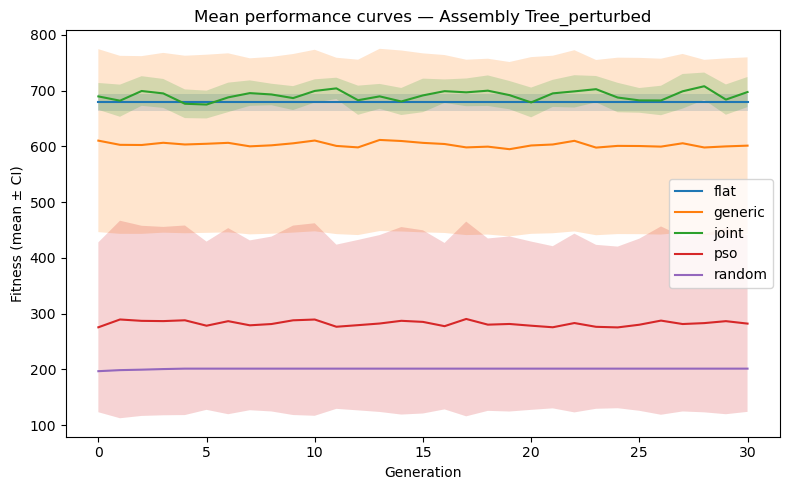

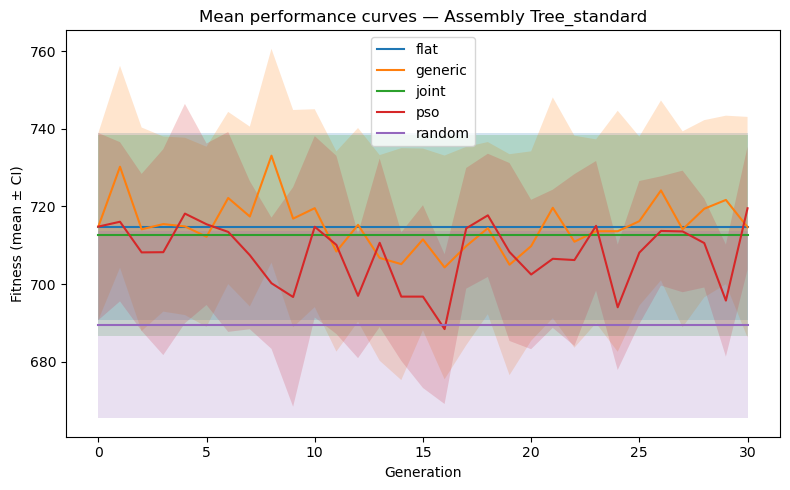

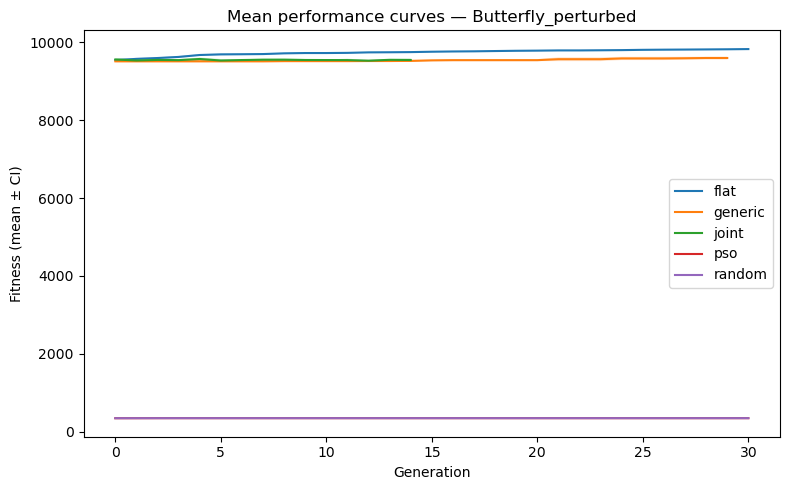

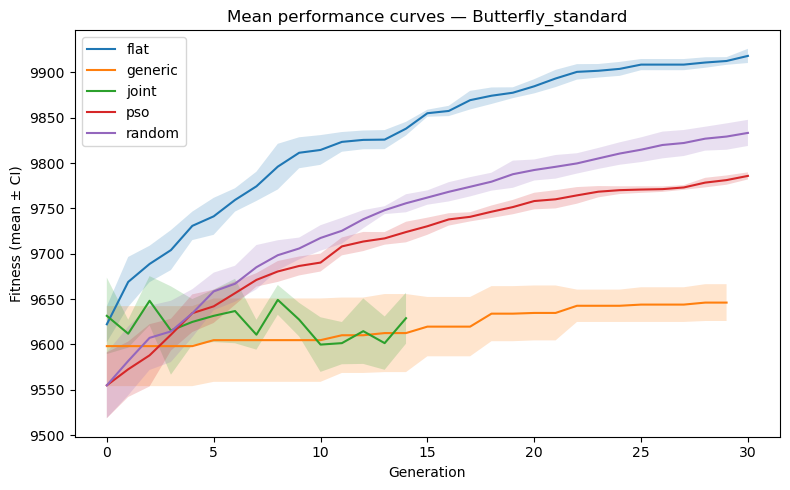

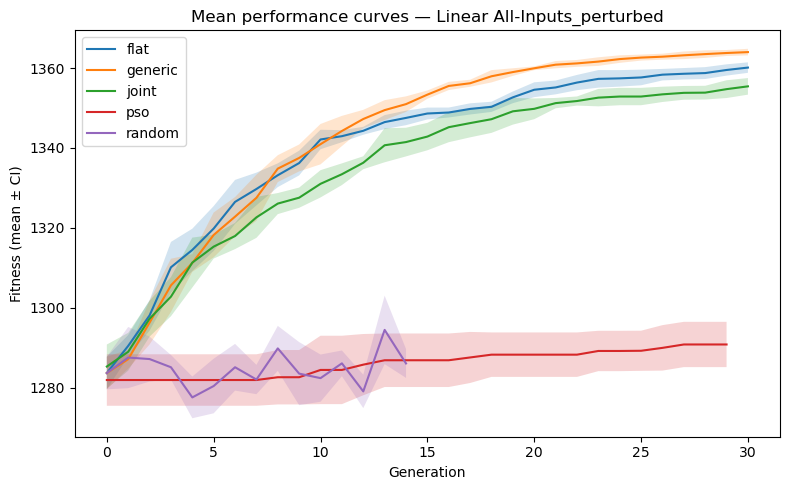

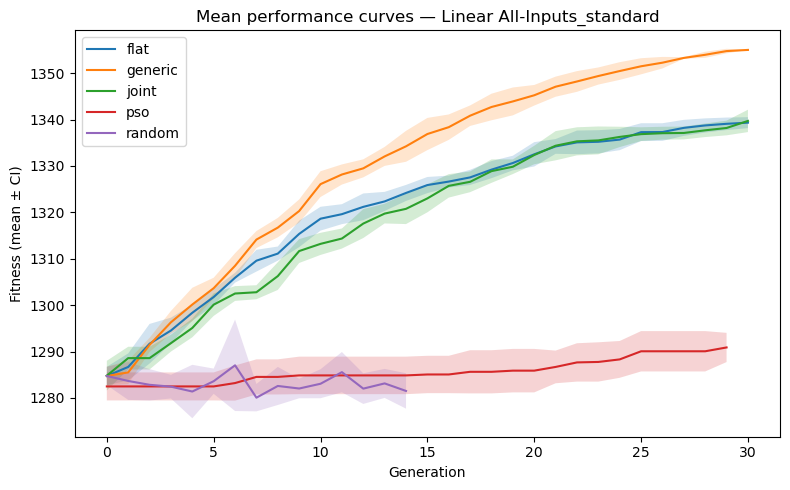

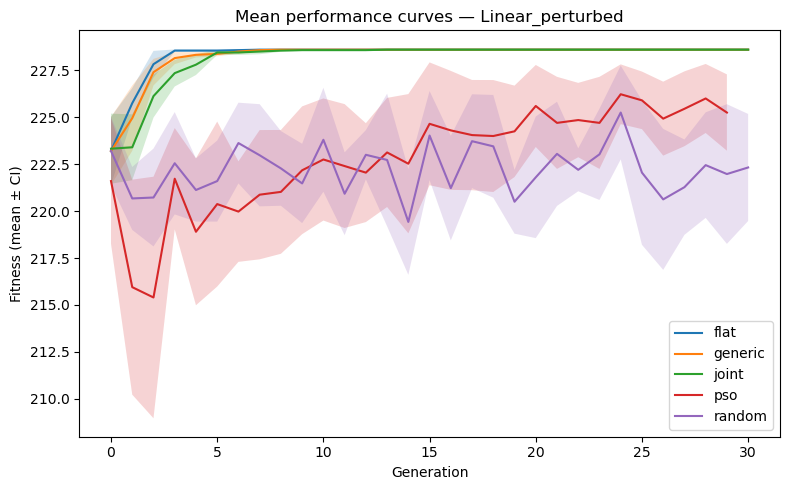

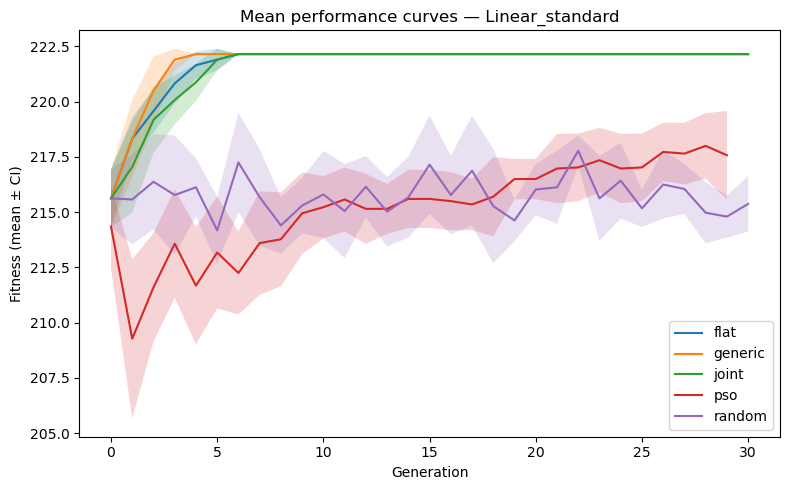

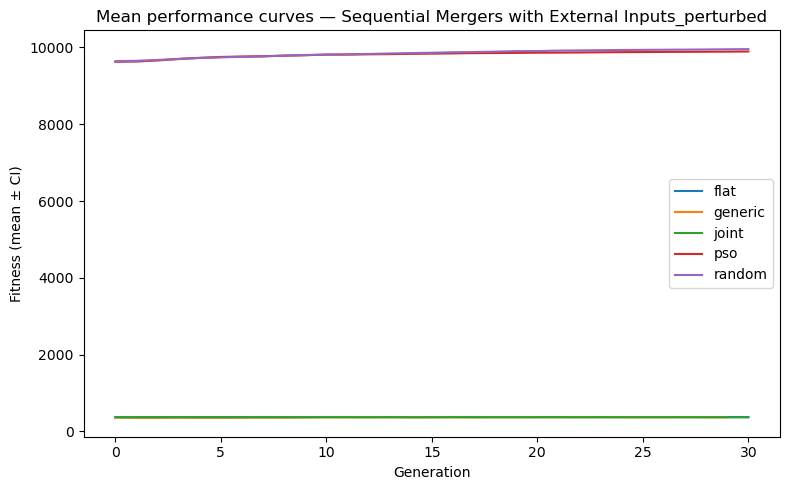

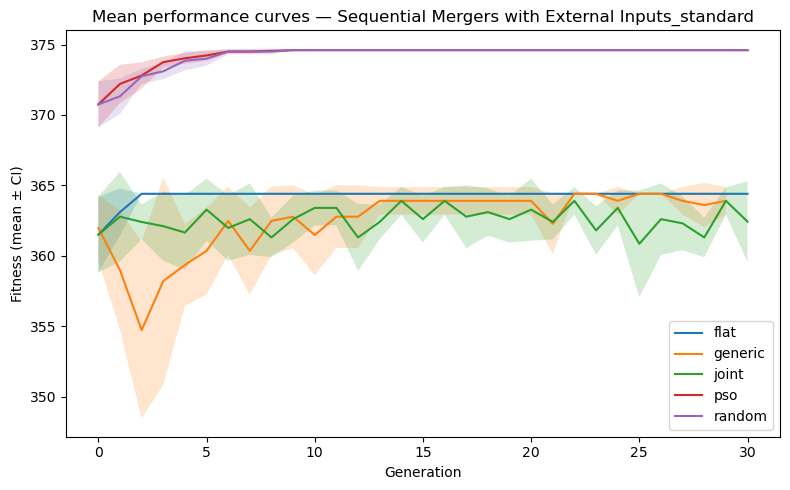

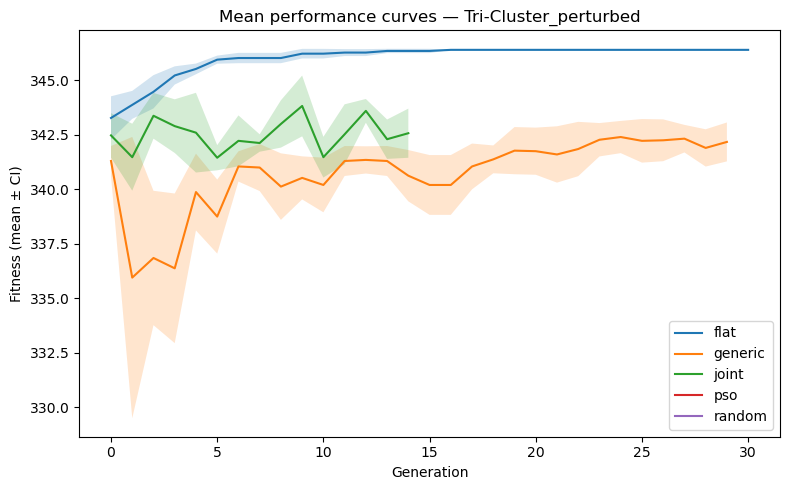

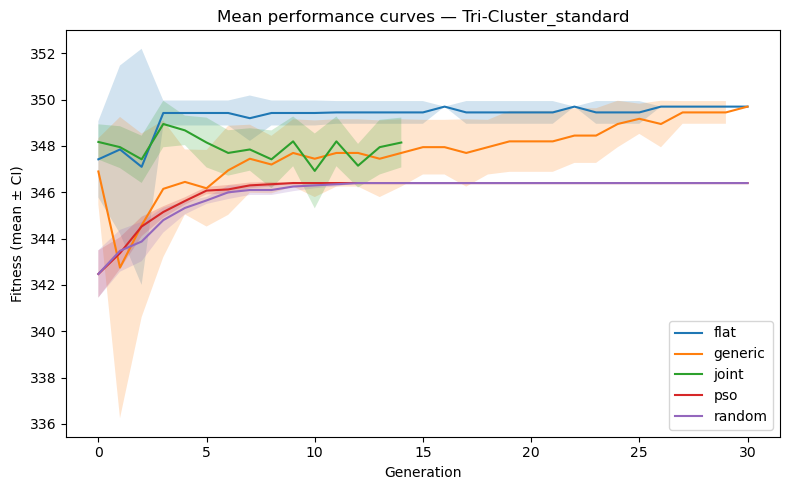

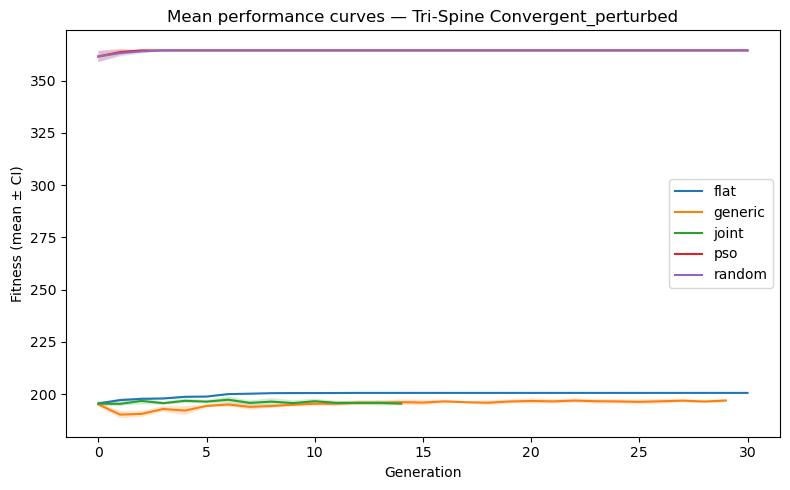

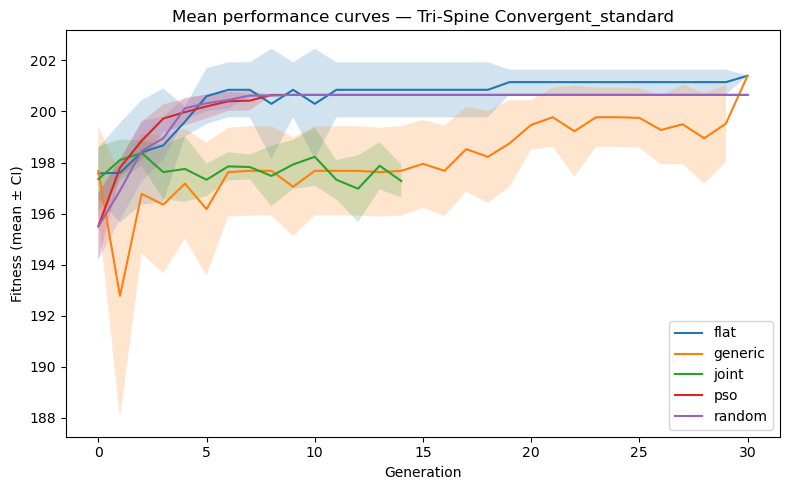

In [91]:
for env in mean_curves["env_name"].unique():
    plt.figure(figsize=(8, 5))
    plt.title(f"Mean performance curves — {env}")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (mean ± CI)")

    for algo in mean_curves["algorithm"].unique():
        # select only rows matching both env and algo
        m_row = mean_curves[(mean_curves["env_name"] == env) &
                            (mean_curves["algorithm"] == algo)]
        s_row = std_curves[(std_curves["env_name"] == env) &
                           (std_curves["algorithm"] == algo)]

        # skip if either is empty (no data for that combination)
        if m_row.empty or s_row.empty:
            continue

        # convert row to numeric array
        generations = np.arange(max_len)
        mean_vals = m_row.iloc[0, 2:].to_numpy(dtype=float)
        std_vals = s_row.iloc[0, 2:].to_numpy(dtype=float)

        n = len(df[(df.env_name == env) & (df.algorithm == algo)])
        ci = 1.96 * std_vals / np.sqrt(n)

        plt.plot(generations, mean_vals, label=algo)
        plt.fill_between(generations, mean_vals - ci, mean_vals + ci, alpha=0.2)

    plt.legend()
    plt.tight_layout()
    plt.show()



### Wilcoxon Test Construction - Tables 

In [ ]:
df_wilcoxon = df[['env_name','run','algorithm','best_value']].copy()
df_wilcoxon.head(5)

,env_name,run,algorithm,best_value
0,Linear_standard,4,flat,222.15
1,Linear_standard,2,flat,222.15
2,Linear_standard,1,flat,222.15
3,Linear_standard,3,flat,222.15
4,Linear_standard,6,flat,222.15
